To the Office of Transportation at The 22nd Century Sporting League,

After our inaugural 2101 season, The League is looking for ways to optimize our game scheduling process and costs.  We know that transportation logistics are a major variable to consider during scheduling, and as such, we’ve got a few questions for you. 

Our primary areas of focus are surrounding the number of jets that The League needs to own, and the cost of fuel for those flights. If we want The League to enjoy continued success, we'll need to make sure we manage transportation costs.

We’re sharing schedule data for the upcoming 2102 season.  On each row, you’ll find information about which teams are needing to travel to their next set of games, the time the flight will likely depart (based on our estimations of gameplay durations) and the time the flight will likely land. 

Additionally, we're also providing the fuel price that was paid each day during this past 2101 season. The fuel price fluctuates over time, but we're hoping you'll be able to project it to the future to help with the analysis.

## The Data

### team_flights.csv

| Column     | Description              |
|------------|--------------------------|
| `team_name` | Official team name |
| `departure_datetime` | Date and Time (in UTC) when the flight will depart |
| `landing_datetime` | Date and Time (in UTC) when the flight will land |


### fuel_price.csv

| Column     | Description              |
|------------|--------------------------|
| `date` | Date when the fuel price was recorded |
| `fuel_price` | Corresponding fuel price (in $ per gallon) |


### Important Things to Know
- You can assume that the flight's average speed is 500 MPH. (So, as an example, a 2-hour flight would travel 1000 miles)
- You can assume that each team’s jet fills up with fuel equivalent to 1 gallon per mile-of-travel 
- You can assume that the jet is fueled on the day the travel departs (and thus can use the fuel price corresponding to the departure date)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy import signal

# Explore the data
team_flights = pd.read_csv('./team_flights.csv')
fuel_prices = pd.read_csv('./fuel_prices_2101.csv',
                         index_col='date')

team_flights.head()

# Some basic data cleaning and pre-processing
team_flights['departure_datetime'] = pd.to_datetime(team_flights['departure_datetime'])
team_flights['landing_datetime']   = pd.to_datetime(team_flights['landing_datetime'])

fuel_prices.index = pd.DatetimeIndex(fuel_prices.index).to_period('D')

In [3]:
team_flights.head()

,team_name,departure_datetime,landing_datetime,travel_distance_miles
0,Agile Antelopes,2102-04-06 21:37:00,2102-04-07 00:35:57,1491.250000
1,Agile Antelopes,2102-04-10 23:57:00,2102-04-11 01:35:40,822.222222
2,Agile Antelopes,2102-04-14 00:29:00,2102-04-14 05:02:55,2282.638889
3,Agile Antelopes,2102-04-21 03:31:00,2102-04-21 05:23:09,934.583333
4,Agile Antelopes,2102-04-24 22:23:00,2102-04-25 00:25:50,1023.611111


In [4]:
team_flights.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1145 entries, 0 to 1144
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   team_name              1145 non-null   object        
 1   departure_datetime     1145 non-null   datetime64[ns]
 2   landing_datetime       1145 non-null   datetime64[ns]
 3   travel_distance_miles  1145 non-null   float64       
dtypes: datetime64[ns](2), float64(1), object(1)
memory usage: 35.9+ KB


In [5]:
team_flights['departure_datetime'].min(), team_flights['landing_datetime'].max()

(Timestamp('2102-04-03 21:40:00'), Timestamp('2102-10-03 00:00:51'))

In [6]:
team_flights['team_name'].unique()

array(['Agile Antelopes', 'Brave Bears', 'Cunning Cougars',
       'Daring Dragons', 'Elegant Eagles', 'Fierce Falcons',
       'Gallant Giants', 'Heroic Hippos', 'Ingenious Iguanas',
       'Jovial Jaguars', 'Knightly Kangaroos', 'Luminous Lions',
       'Mighty Mammoths', 'Noble Narwhals', 'Ominous Owls',
       'Proud Panthers', 'Quick Quails', 'Rapid Rabbits',
       'Shining Sharks', 'Tough Tigers', 'Unyielding Urchins',
       'Valiant Vipers', 'Wise Wolves', 'Xenial Xerus', 'Youthful Yaks',
       'Zealous Zebras', 'Angry Alpacas', 'Bumbling Beavers',
       'Crazed Crocs', 'Diligent Data Scientists'], dtype=object)

In [7]:
# Create an array of all unique datetime events (departures and landings)
events = pd.concat([
    pd.DataFrame({'datetime': team_flights['departure_datetime'], 'change': 1}),
    pd.DataFrame({'datetime': team_flights['landing_datetime'], 'change': -1})
]).sort_values('datetime')

# The error was here: reset_index('datetime') tries to reset a level named 'datetime', 
# but 'datetime' is a column, not the index. 
# To reset the index and keep 'datetime' as a column, just use reset_index(drop=True)
events = events.set_index('datetime')

# Calculate the number of flights mid-air at each event
events['number_in_air'] = events['change'].cumsum()

# Display the datetimes and corresponding number of flights mid-air
events['number_in_air']

datetime
2102-04-03 21:40:00    1
2102-04-03 21:40:00    2
2102-04-03 21:52:00    3
2102-04-03 22:02:00    4
2102-04-03 22:04:00    5
                      ..
2102-09-30 07:12:27    2
2102-09-30 07:16:51    1
2102-09-30 09:28:32    0
2102-10-02 23:22:00    1
2102-10-03 00:00:51    0
Name: number_in_air, Length: 2290, dtype: int64

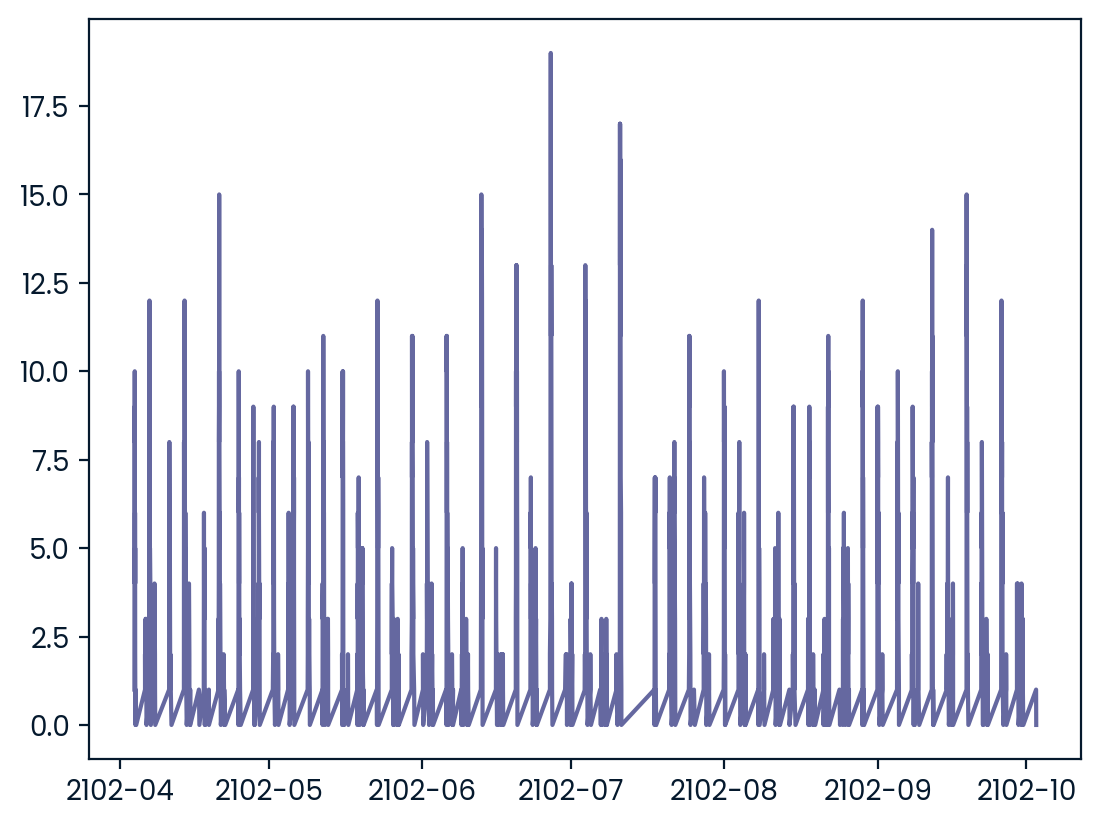

In [8]:
plt.plot(events.index, events['number_in_air'])
plt.show()

In [9]:
max_teams_in_flight = int(events['number_in_air'].max())
max_teams_in_flight

19

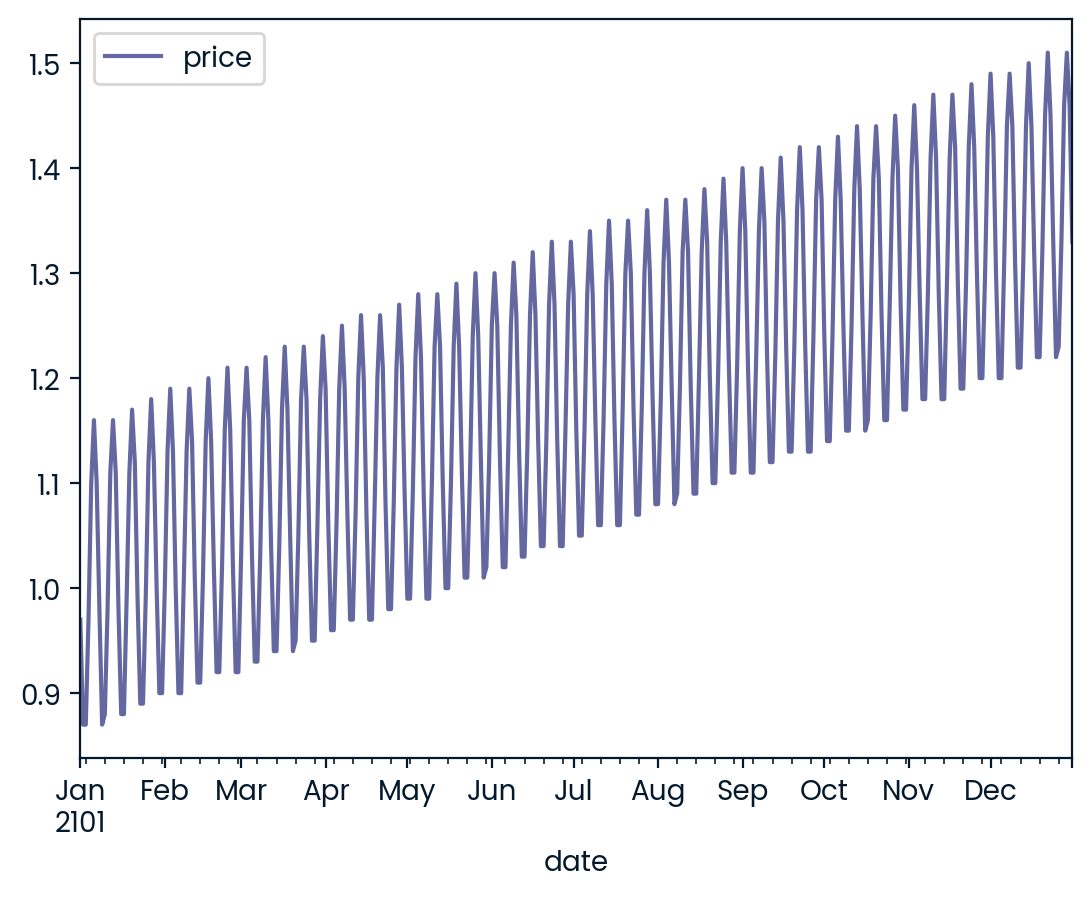

In [10]:
fuel_prices.head()
fuel_prices.plot()
plt.show()

In [ ]:
# Run Augmented Dickey-Fuller test
adf_result = adfuller(fuel_prices['price'].dropna())
adf_output = {
    'ADF Statistic': adf_result[0],
    'p-value': adf_result[1]
}

# Run KPSS test
kpss_result = kpss(fuel_prices['price'].dropna(), regression='ct')
kpss_output = {
    'KPSS Statistic': kpss_result[0],
    'p-value': kpss_result[1]
}

adf_output, kpss_output

/tmp/ipykernel_374/4097206750.py:11: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.




({'ADF Statistic': 0.10529145706829932, 'p-value': 0.9664205149823116},
 {'KPSS Statistic': 0.4229879795585553, 'p-value': 0.01})

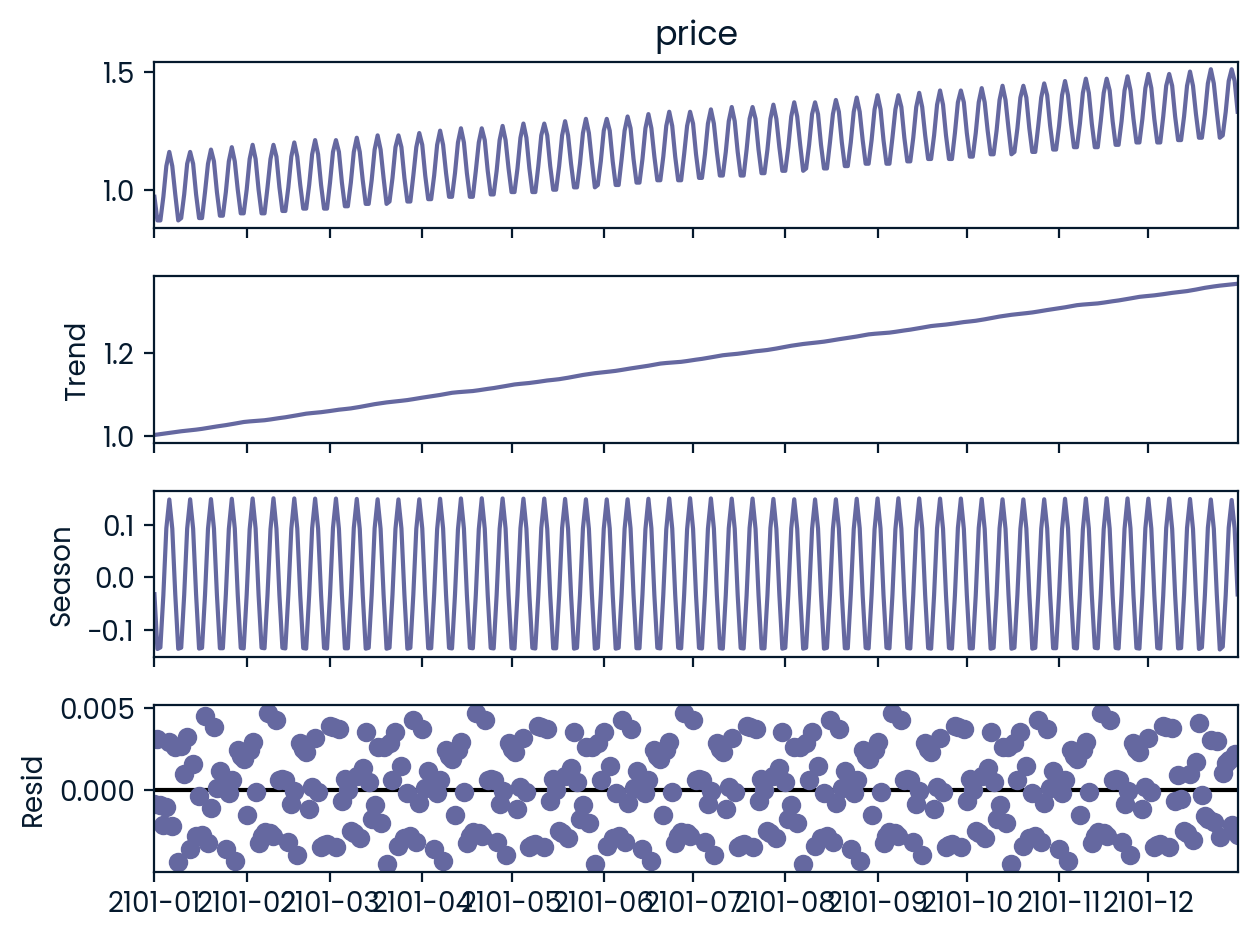

In [ ]:
# Ensure the index is a pandas DatetimeIndex with a frequency set
fuel_prices = fuel_prices.copy()
fuel_prices = fuel_prices.sort_index()  # Ensure sorted by date
fuel_prices = fuel_prices.loc[~fuel_prices.index.duplicated()]  # Remove duplicate indices if any

# If the index is a PeriodIndex, convert to DatetimeIndex using to_timestamp()
if isinstance(fuel_prices.index, pd.PeriodIndex):
    fuel_prices.index = fuel_prices.index.to_timestamp()

# If the index is not a DatetimeIndex, convert it
if not isinstance(fuel_prices.index, pd.DatetimeIndex):
    fuel_prices.index = pd.to_datetime(fuel_prices.index)

# Try to infer frequency if not set
if fuel_prices.index.freq is None:
    inferred_freq = pd.infer_freq(fuel_prices.index)
    if inferred_freq is not None:
        fuel_prices = fuel_prices.asfreq(inferred_freq)

# Perform STL decomposition
stl = STL(fuel_prices['price'].dropna(), period=7)
stl_result = stl.fit()

# Plot the decomposition
fig = stl_result.plot()
plt.show()

<AxesSubplot: xlabel='date'>

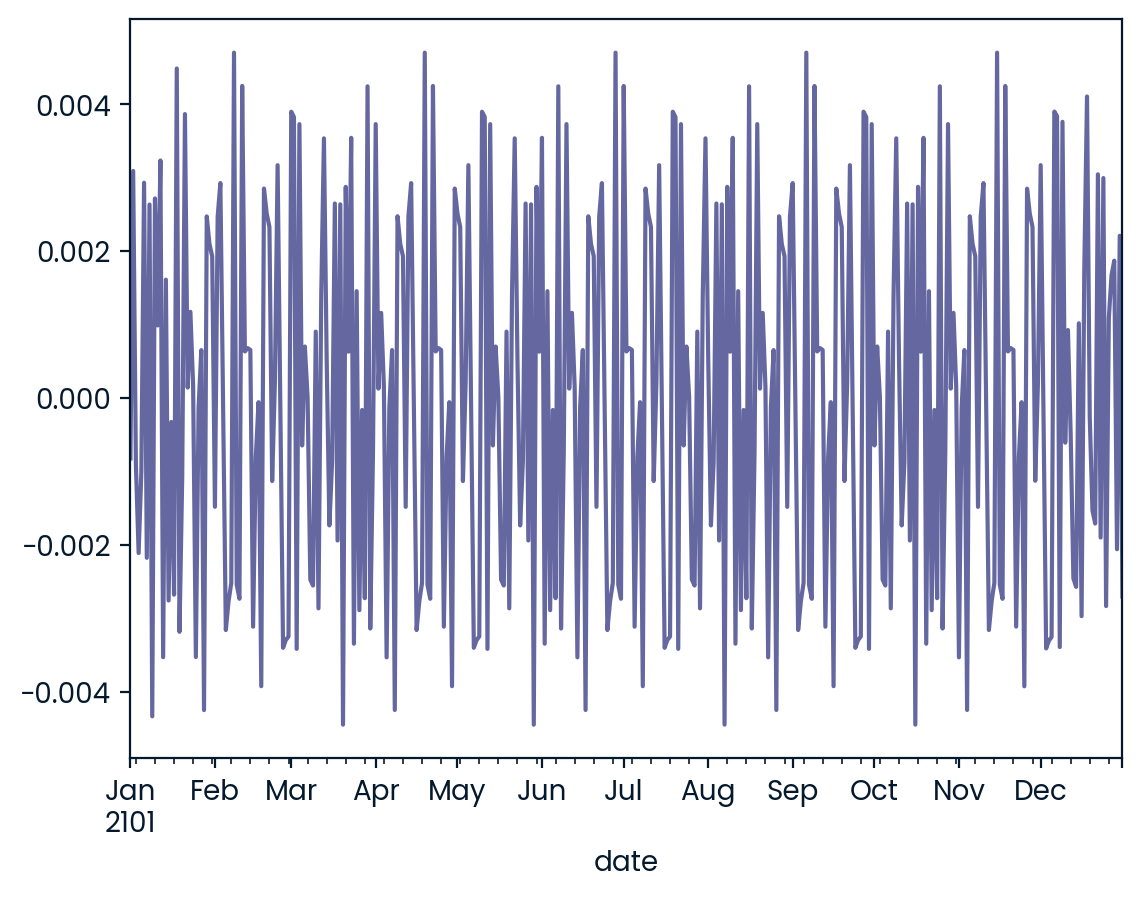

In [14]:
resud = stl_result.resid
resud.plot()

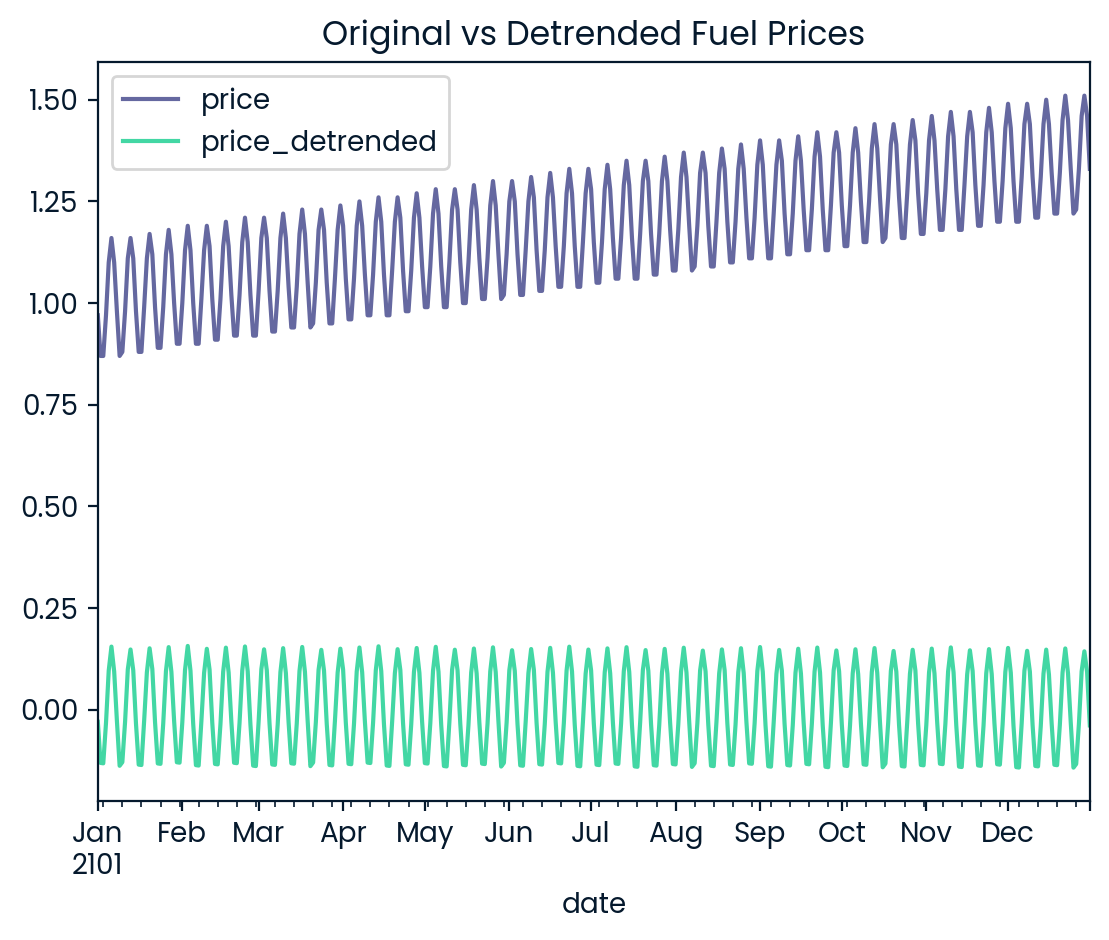

In [ ]:
# Remove linear trend from the 'price' column
fuel_prices['price_detrended'] = signal.detrend(fuel_prices['price'].values)

# Plot the original and detrended prices for comparison
fuel_prices[['price', 'price_detrended']].plot()
plt.title('Original vs Detrended Fuel Prices')
plt.show()

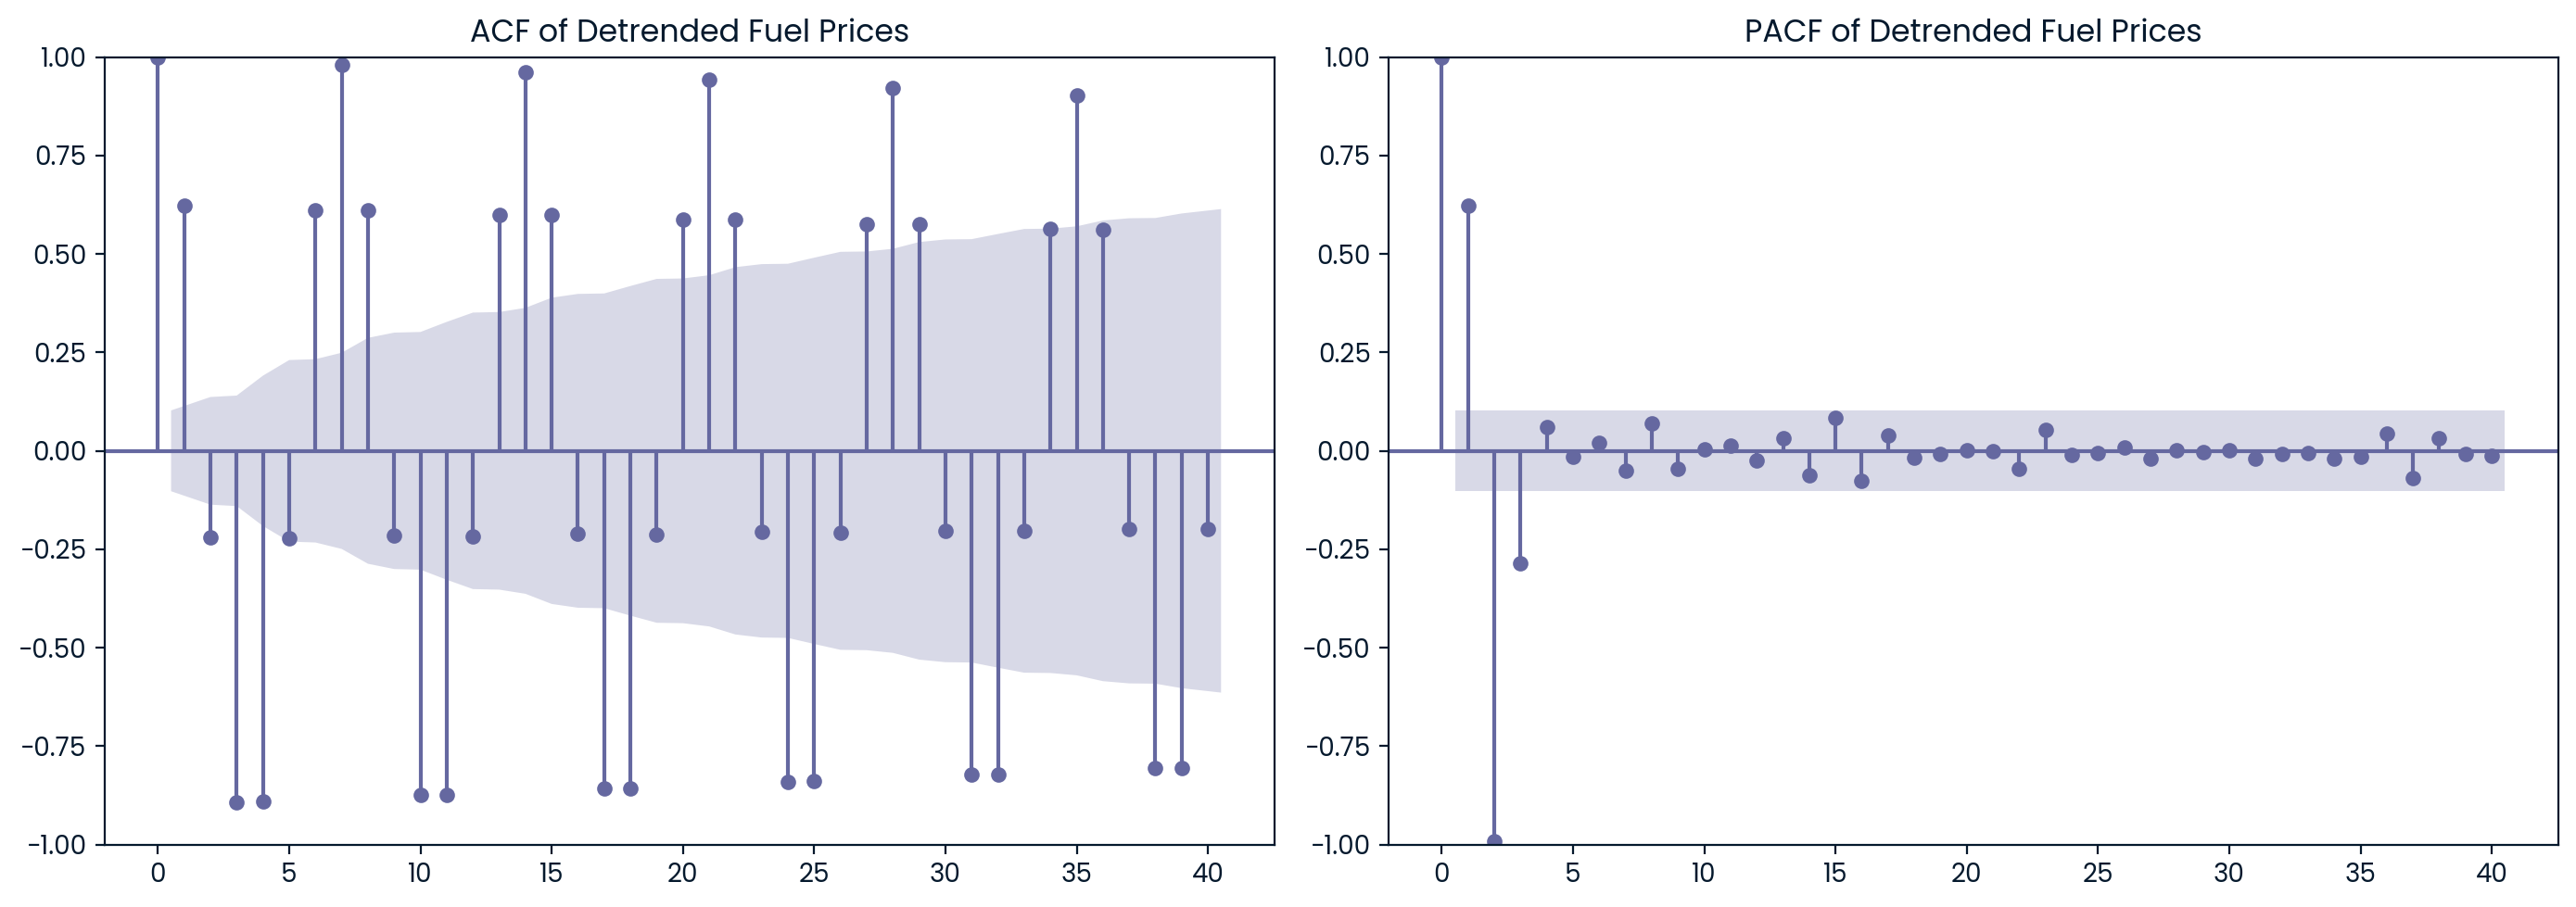

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot ACF
plot_acf(fuel_prices['price_detrended'], ax=axes[0], lags=40)
axes[0].set_title('ACF of Detrended Fuel Prices')

# Plot PACF
plot_pacf(fuel_prices['price_detrended'], ax=axes[1], lags=40)
axes[1].set_title('PACF of Detrended Fuel Prices')

plt.tight_layout()
plt.show()

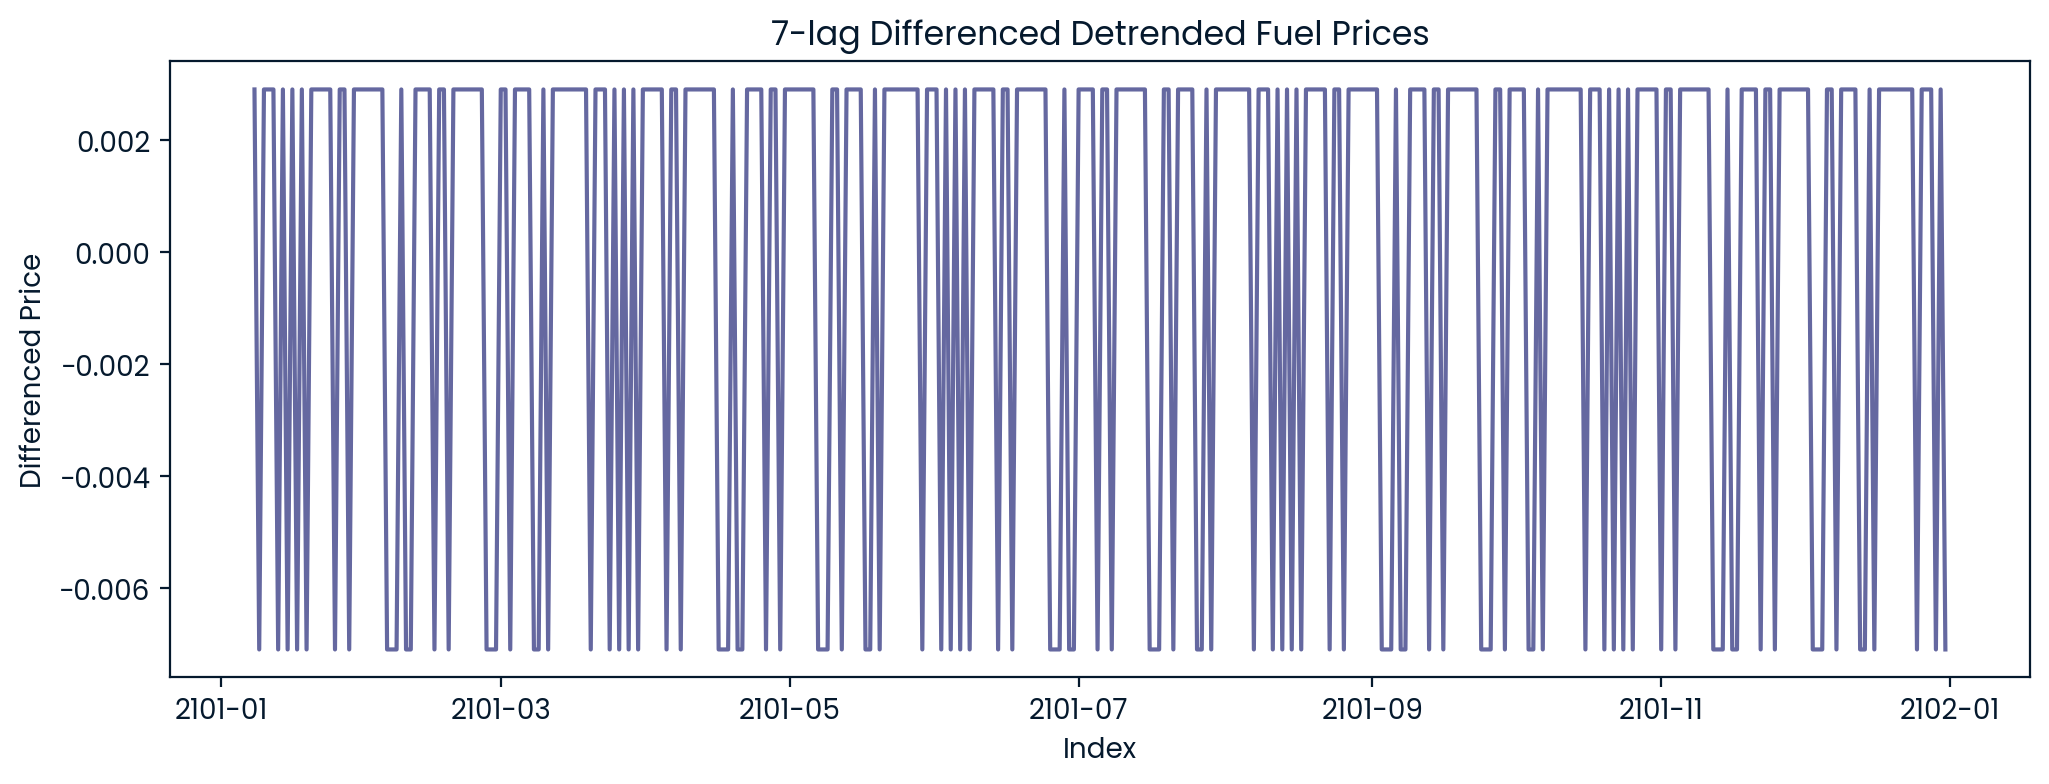

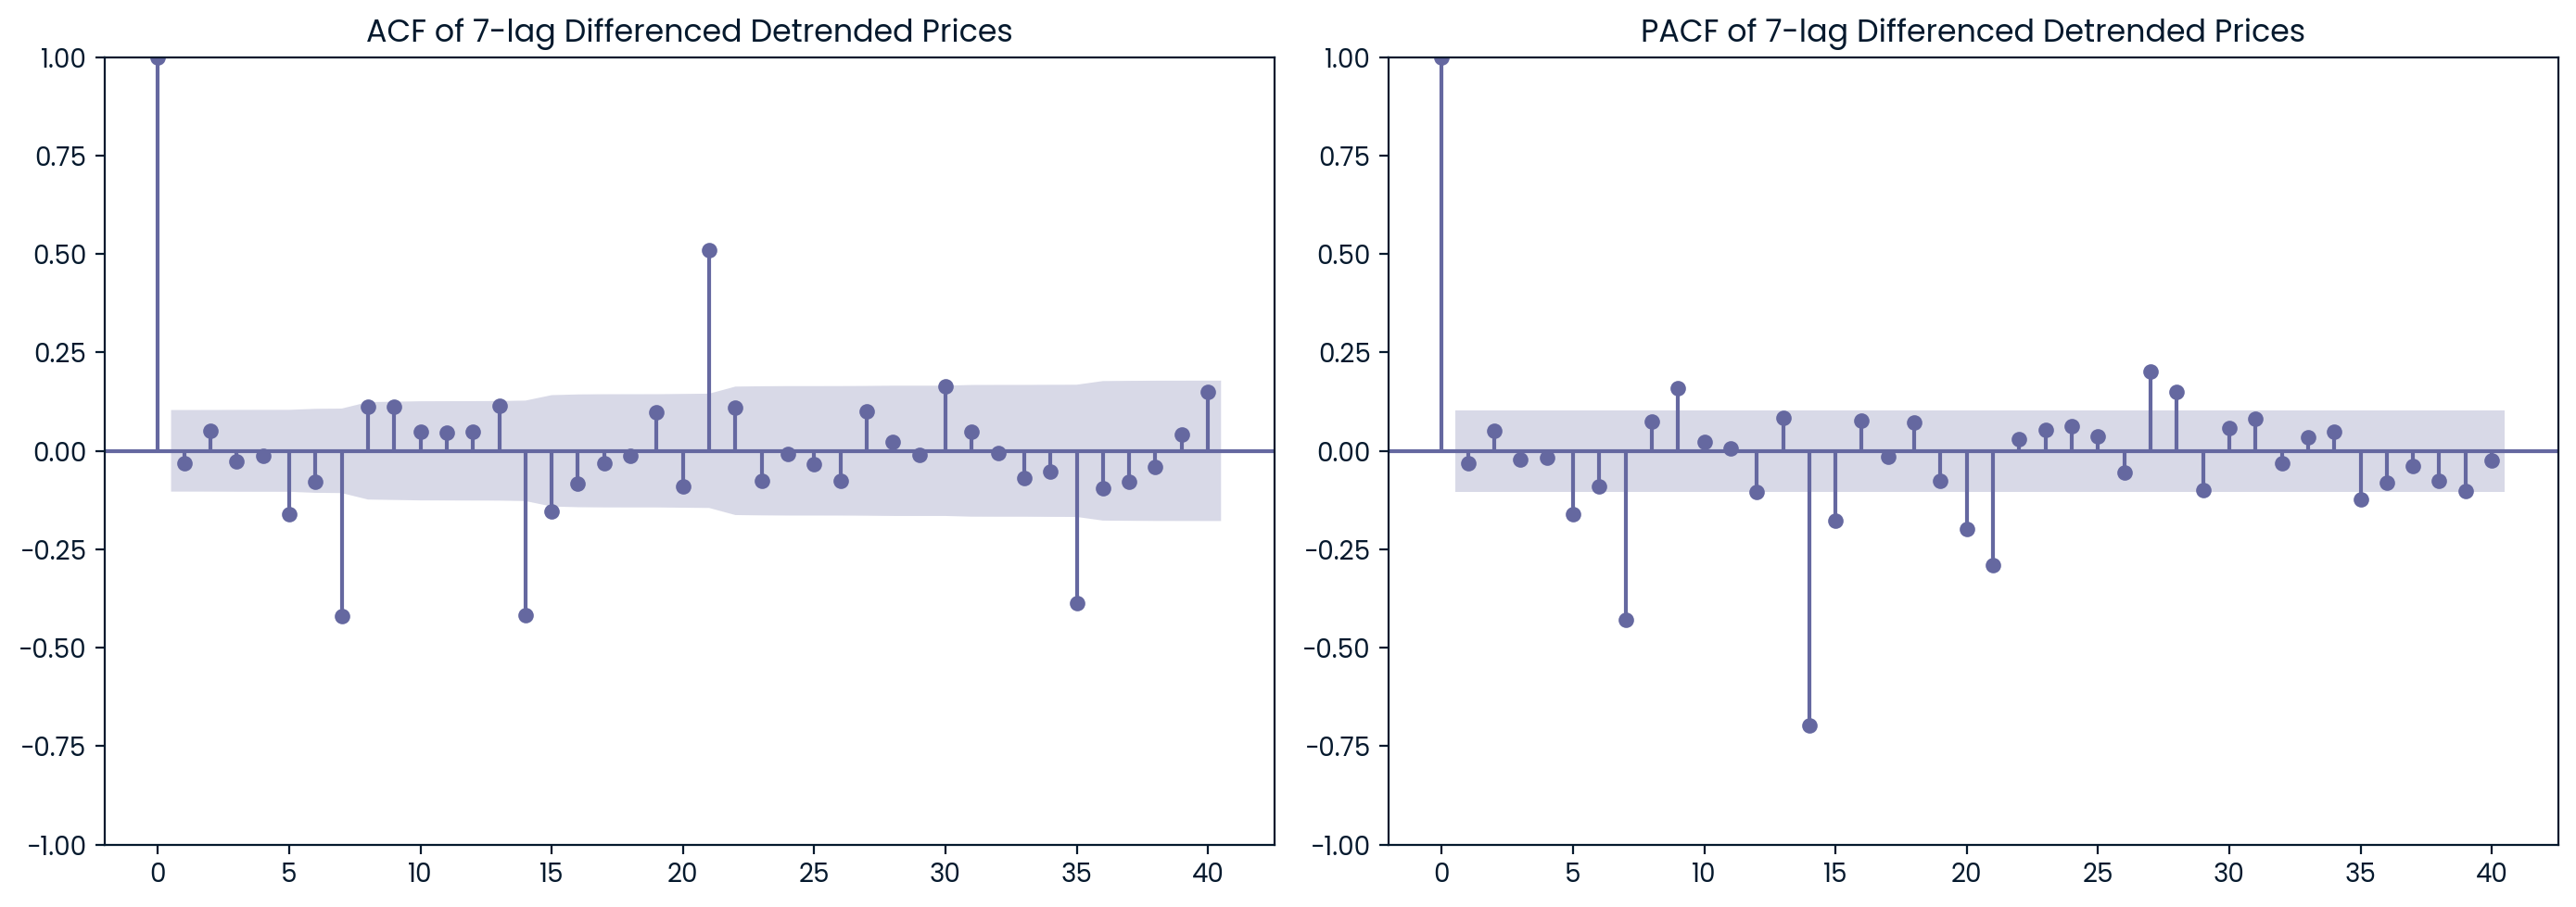

ADF Statistic: -9.542580615191897
p-value: 2.7018203871579786e-16
Critical Value (1%): -3.4496162602188187
Critical Value (5%): -2.870028369720798
Critical Value (10%): -2.5712922615505627

KPSS Statistic: 0.007912890544175571
p-value: 0.1
Critical Value (10%): 0.347
Critical Value (5%): 0.463
Critical Value (2.5%): 0.574
Critical Value (1%): 0.739


/tmp/ipykernel_374/2957447265.py:28: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.




In [18]:
diff_7 = fuel_prices['price_detrended'].diff(7).dropna()

# Plot the differenced series
plt.figure(figsize=(12, 4))
plt.plot(diff_7)
plt.title("7-lag Differenced Detrended Fuel Prices")
plt.xlabel("Index")
plt.ylabel("Differenced Price")
plt.show()

# Plot ACF and PACF
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_acf(diff_7, ax=axes[0], lags=40)
axes[0].set_title('ACF of 7-lag Differenced Detrended Prices')
plot_pacf(diff_7, ax=axes[1], lags=40)
axes[1].set_title('PACF of 7-lag Differenced Detrended Prices')
plt.tight_layout()
plt.show()

# Run Augmented Dickey-Fuller test
adf_result = adfuller(diff_7)
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
for key, value in adf_result[4].items():
    print(f'Critical Value ({key}): {value}')

# Run KPSS test
kpss_result = kpss(diff_7, regression='c', nlags="auto")
print("\nKPSS Statistic:", kpss_result[0])
print("p-value:", kpss_result[1])
for key, value in kpss_result[3].items():
    print(f'Critical Value ({key}): {value}')

In [132]:
adf_result = adfuller(resud.dropna())
adf_output = {
    'ADF Statistic': adf_result[0],
    'p-value': adf_result[1]
}

# Run KPSS test
kpss_result = kpss(resud.dropna(), regression='c')
kpss_output = {
    'KPSS Statistic': kpss_result[0],
    'p-value': kpss_result[1]
}

adf_output, kpss_output

/tmp/ipykernel_403/1526501858.py:8: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.




({'ADF Statistic': -7.862687524385988, 'p-value': 5.232966312422331e-12},
 {'KPSS Statistic': 0.028594932588734898, 'p-value': 0.1})

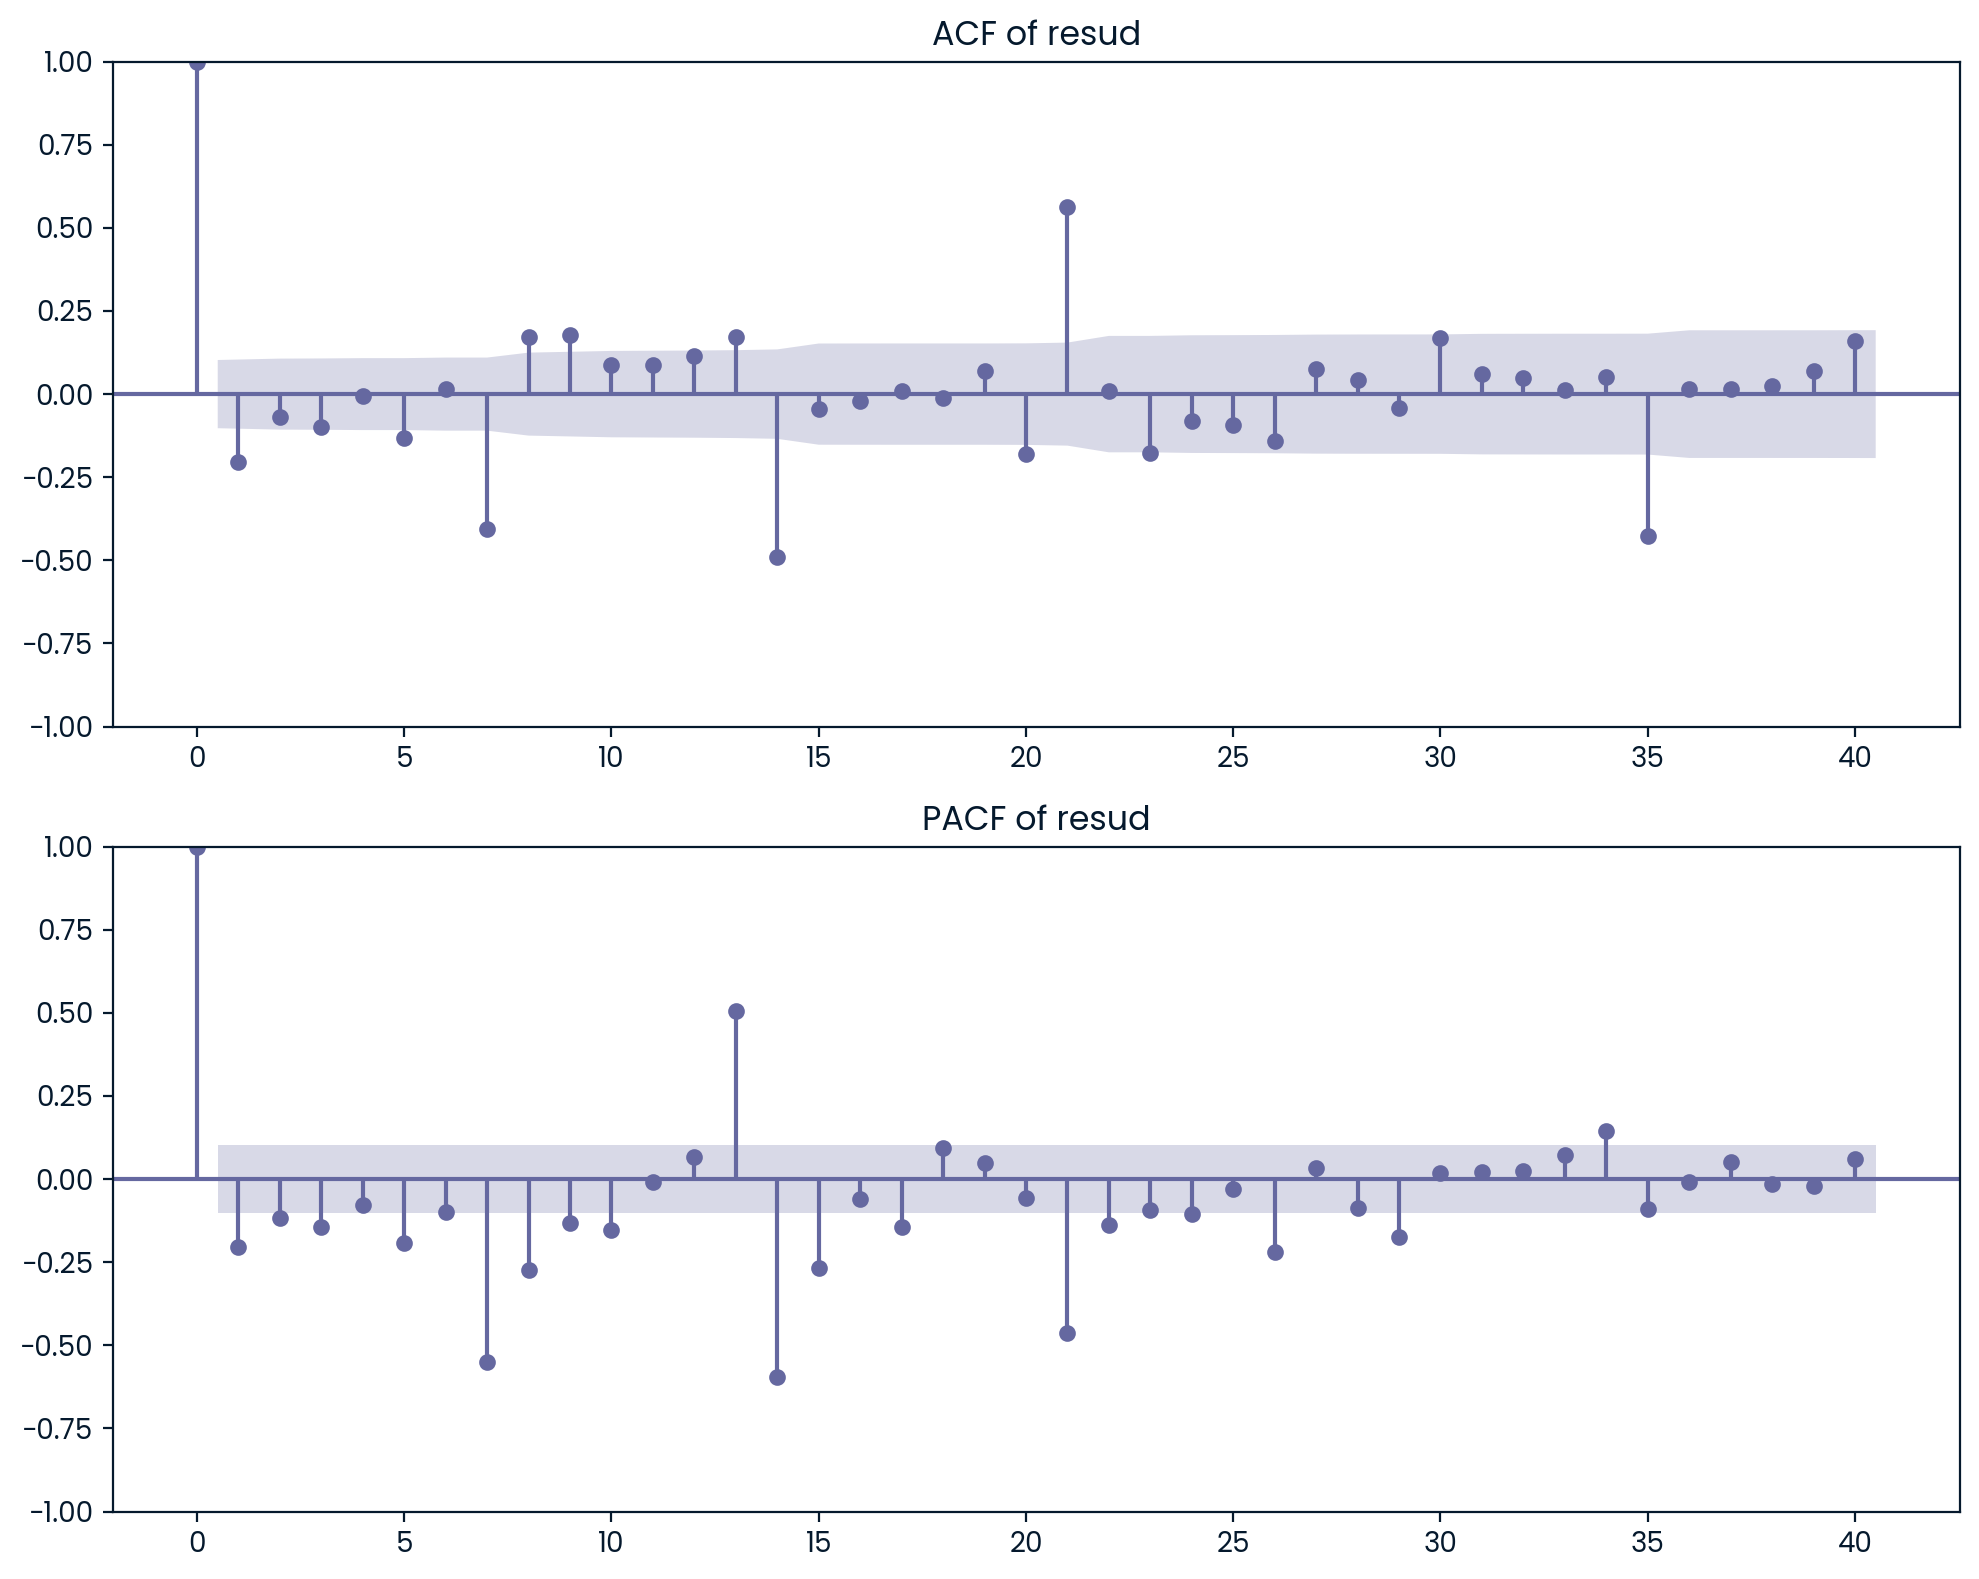

In [20]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

plot_acf(resud.dropna(), lags=40, ax=axes[0])
axes[0].set_title('ACF of resud')

plot_pacf(resud.dropna(), lags=40, ax=axes[1])
axes[1].set_title('PACF of resud')

plt.tight_layout()
plt.show()

In [136]:
order = (0, 1, 2)
seasonal_order = (3, 2, 1, 7)
sarimax_model = SARIMAX(
    fuel_prices['price'].dropna(),
    order=order,
    seasonal_order=seasonal_order
)
sarimax_result = sarimax_model.fit(disp=False)
sarimax_result.summary()

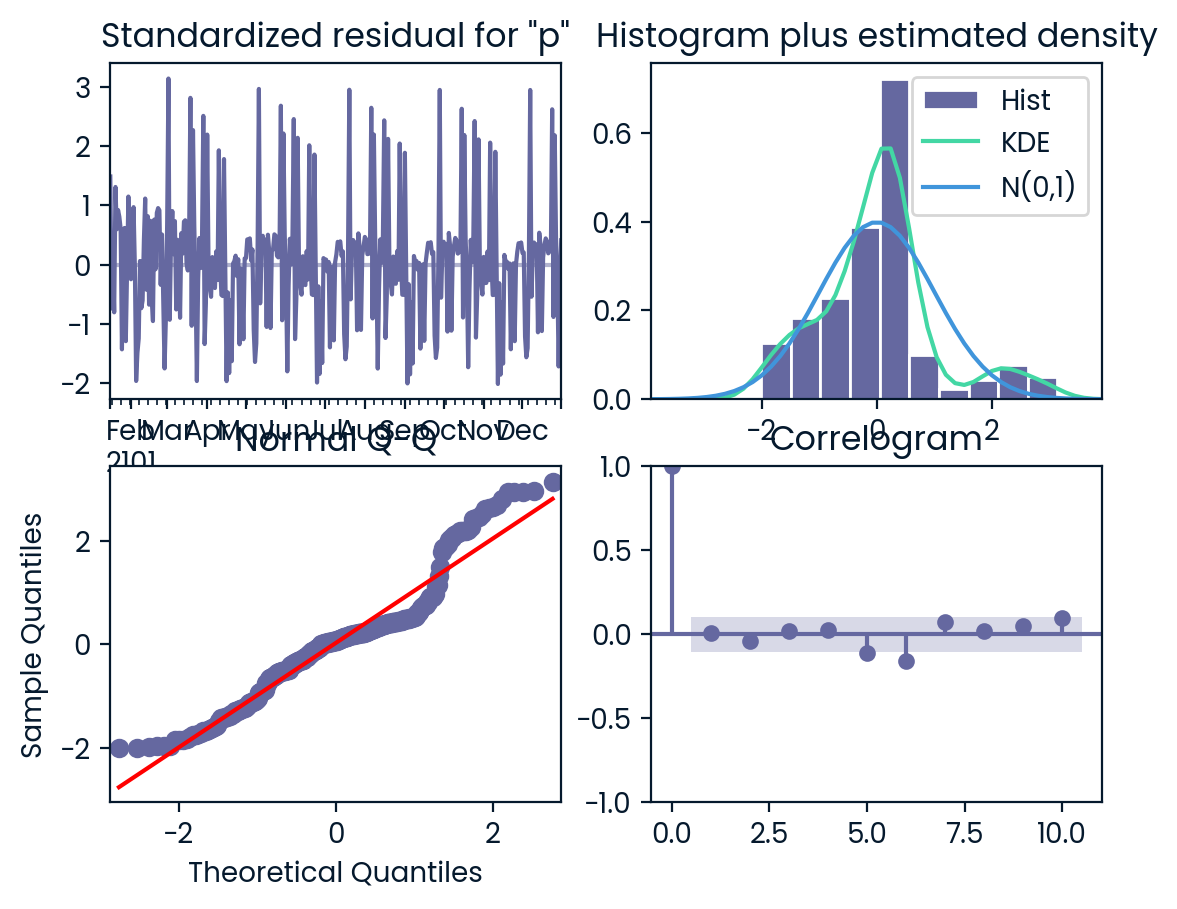

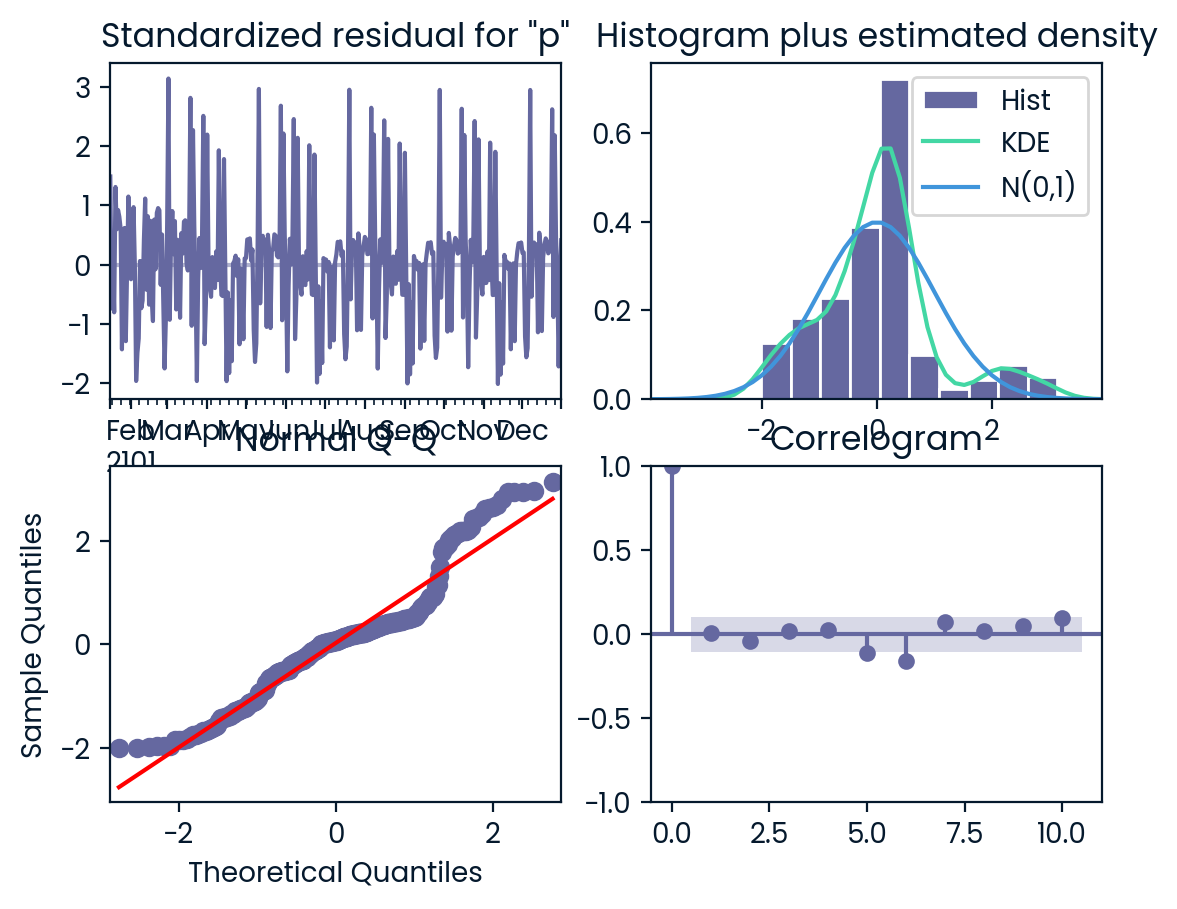

In [137]:
sarimax_result.plot_diagnostics()

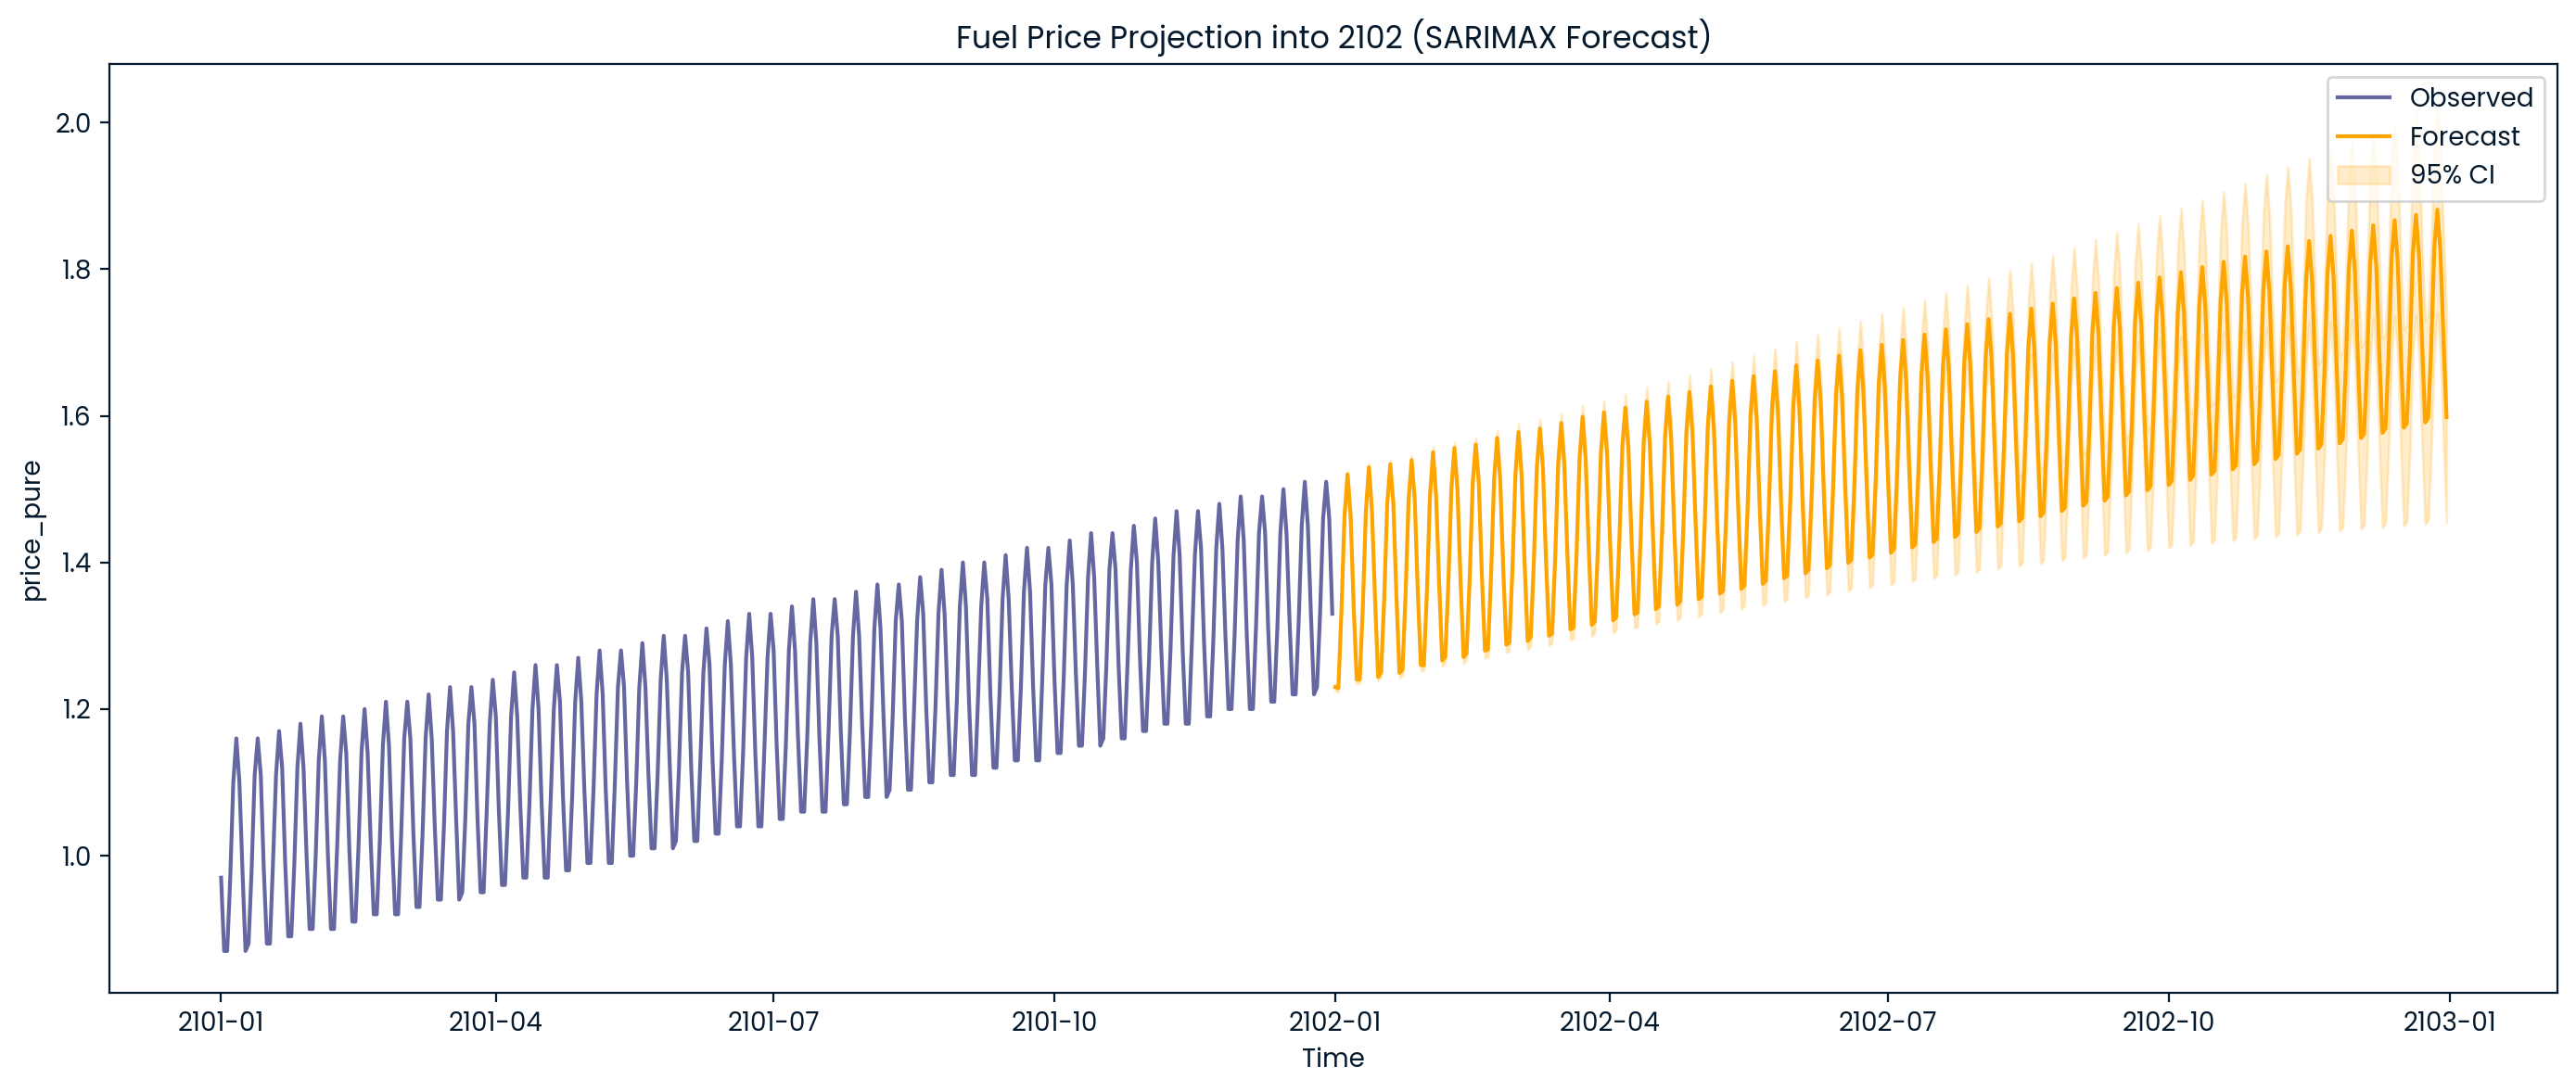

In [138]:
# Forecast approximately one more year (assume daily data, so 365 days)
n_forecast = 365
forecast_result = sarimax_result.get_forecast(steps=n_forecast)
forecast_mean = forecast_result.predicted_mean
forecast_ci = forecast_result.conf_int()

# Plot the observed data and the forecast
plt.figure(figsize=(14, 6))
plt.plot(fuel_prices['price'], label='Observed')
plt.plot(
    forecast_mean.index,
    forecast_mean,
    label='Forecast',
    color='orange'
)
plt.fill_between(
    forecast_mean.index,
    forecast_ci.iloc[:, 0],
    forecast_ci.iloc[:, 1],
    color='orange',
    alpha=0.2,
    label='95% CI'
)
plt.title('Fuel Price Projection into 2102 (SARIMAX Forecast)')
plt.xlabel('Time')
plt.ylabel('price_pure')
plt.legend()
plt.tight_layout()
plt.show()

In [139]:
forecast_result.summary_frame()

price,mean,mean_se,mean_ci_lower,mean_ci_upper
2102-01-01,1.229868,0.002653,1.224669,1.235067
2102-01-02,1.228732,0.002687,1.223465,1.233999
2102-01-03,1.333791,0.002697,1.328505,1.339078
2102-01-04,1.464172,0.002707,1.458866,1.469478
2102-01-05,1.520140,0.002717,1.514815,1.525465
...,...,...,...,...
2102-12-27,1.829606,0.071870,1.688744,1.970469
2102-12-28,1.881242,0.072211,1.739710,2.022773
2102-12-29,1.824325,0.072550,1.682130,1.966519
2102-12-30,1.705347,0.072892,1.562482,1.848213


In [140]:
projections = pd.DataFrame(
    forecast_result.predicted_mean.values,
    index=forecast_result.summary_frame().index,
    columns = ['predicted']
)
projections.head()

,predicted
2102-01-01,1.229868
2102-01-02,1.228732
2102-01-03,1.333791
2102-01-04,1.464172
2102-01-05,1.520140


In [141]:
# Ensure departure_datetime is datetime and extract date as dt.date
team_flights = team_flights.copy()
team_flights['departure_date'] = team_flights['departure_datetime'].dt.date

# Prepare projections DataFrame: ensure index is date (dt.date)
projections = projections.copy()
projections.index = pd.to_datetime(projections.index).date
projections.index.name = 'departure_date'

# Join predicted price onto team_flights using departure_date
team_flights = team_flights.set_index('departure_date').join(
    projections,
    how='left'
).reset_index()

# Compute cost per flight: 1 gallon per mile, so cost = price * miles
team_flights['fuel_cost'] = team_flights['predicted'] * team_flights['travel_distance_miles']

# Compute overall cost for all flights in 2102
total_fuel_spend_2102_dollars = team_flights['fuel_cost'].sum()

team_flights.head(), total_fuel_spend_2102_dollars

(  departure_date       team_name  ... predicted    fuel_cost
 0     2102-04-03  Daring Dragons  ...  1.325198   340.686415
 1     2102-04-03  Elegant Eagles  ...  1.325198  1104.147921
 2     2102-04-03  Proud Panthers  ...  1.325198   101.230431
 3     2102-04-03    Quick Quails  ...  1.325198  1244.029972
 4     2102-04-03   Rapid Rabbits  ...  1.325198  1035.127173
 
 [5 rows x 7 columns],
 1869558.8387321336)

In [142]:
team_flights.head()

,departure_date,team_name,departure_datetime,landing_datetime,travel_distance_miles,predicted,fuel_cost
0,2102-04-03,Daring Dragons,2102-04-03 23:17:00,2102-04-03 23:47:51,257.083333,1.325198,340.686415
1,2102-04-03,Elegant Eagles,2102-04-03 21:40:00,2102-04-03 23:19:59,833.194444,1.325198,1104.147921
2,2102-04-03,Proud Panthers,2102-04-03 23:17:00,2102-04-03 23:26:10,76.388889,1.325198,101.230431
3,2102-04-03,Quick Quails,2102-04-03 23:16:00,2102-04-04 01:08:39,938.750000,1.325198,1244.029972
4,2102-04-03,Rapid Rabbits,2102-04-03 21:40:00,2102-04-03 23:13:44,781.111111,1.325198,1035.127173
